In [13]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [14]:
# Load the Pima Indians Diabetes dataset.
data = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True,
    parser="auto"
)

# Store the features.
X = data.data

# Convert the target into numeric labels.
# 0 = No Diabetes
# 1 = Diabetes
y = (data.target == "tested_positive").astype(int)
y = pd.Series(y.values, name="target")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (768, 8)
Target shape: (768,)


,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


0    1
1    0
2    1
3    0
4    1
Name: target, dtype: int64

In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [16]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insu,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


In [17]:
missing_values = X.isnull().sum().sum()
print("Total missing values:", missing_values)

Total missing values: 0


target
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

Class percentages:
target
0    65.1
1    34.9
Name: proportion, dtype: float64


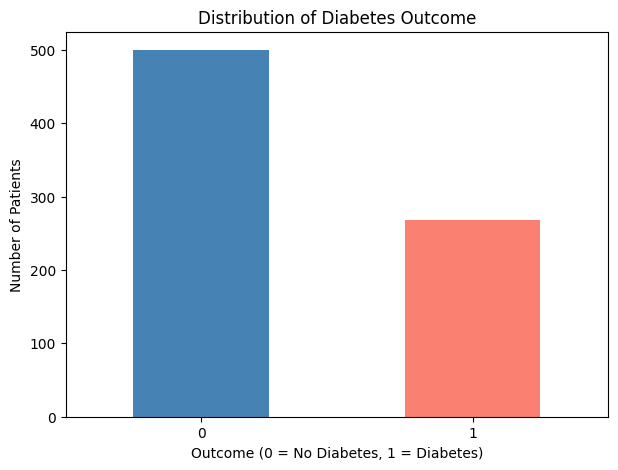

In [18]:
print(y.value_counts().sort_index().rename({0: "No Diabetes", 1: "Diabetes"}))

print("\nClass percentages:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

plt.figure(figsize=(7, 5))
y.value_counts().sort_index().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [19]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)


Training features: (614, 8)
Testing features : (154, 8)
Training target  : (614,)
Testing target   : (154,)


In [20]:
# Standardize the Features
# KNN uses distances, so the features should be standardized.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Convert the standardized training array back to a DataFrame.
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

# Calculate the mean of each standardized training feature.
scaled_means = X_train_scaled_df.mean()

# Calculate the standard deviation of each standardized training feature.
scaled_stds = X_train_scaled_df.std()


print("First five feature means after scaling:")
print(scaled_means.head())


print("\nFirst five feature standard deviations after scaling:")
print(scaled_stds.head())


First five feature means after scaling:
preg   -6.943414e-17
plas    1.735854e-16
pres   -2.097490e-16
skin   -3.471707e-17
insu   -1.591199e-17
dtype: float64

First five feature standard deviations after scaling:
preg    1.000815
plas    1.000815
pres    1.000815
skin    1.000815
insu    1.000815
dtype: float64


RESULTS FOR K = 1
Training Accuracy: 1.0000
Testing Accuracy : 0.7078
Precision        : 0.5882
Recall           : 0.5556
F1-Score         : 0.5714

              precision    recall  f1-score   support

 No Diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



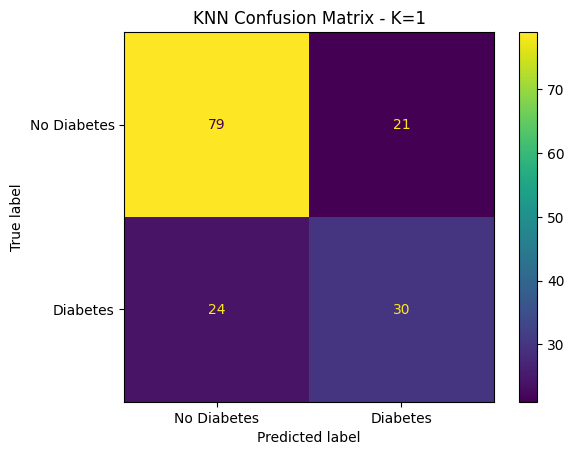

RESULTS FOR K = 3
Training Accuracy: 0.8632
Testing Accuracy : 0.6948
Precision        : 0.5686
Recall           : 0.5370
F1-Score         : 0.5524

              precision    recall  f1-score   support

 No Diabetes       0.76      0.78      0.77       100
    Diabetes       0.57      0.54      0.55        54

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.69      0.69      0.69       154



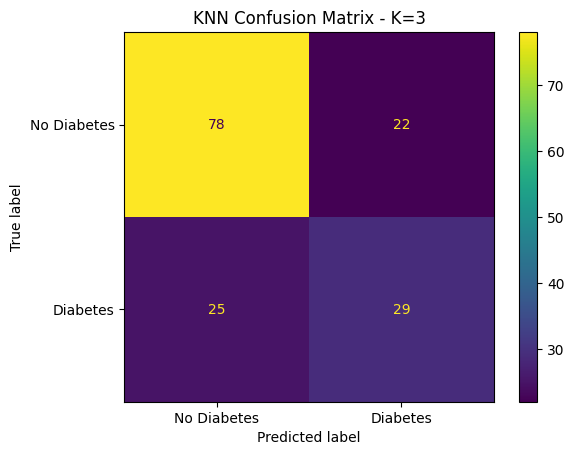

RESULTS FOR K = 5
Training Accuracy: 0.8062
Testing Accuracy : 0.7013
Precision        : 0.5833
Recall           : 0.5185
F1-Score         : 0.5490

              precision    recall  f1-score   support

 No Diabetes       0.75      0.80      0.78       100
    Diabetes       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



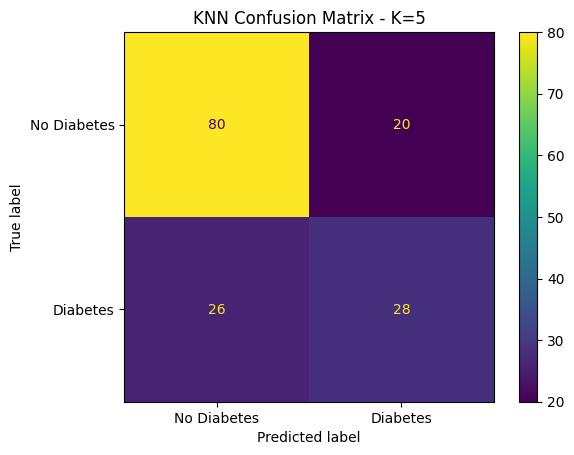

RESULTS FOR K = 7
Training Accuracy: 0.8062
Testing Accuracy : 0.7468
Precision        : 0.6596
Recall           : 0.5741
F1-Score         : 0.6139

              precision    recall  f1-score   support

 No Diabetes       0.79      0.84      0.81       100
    Diabetes       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



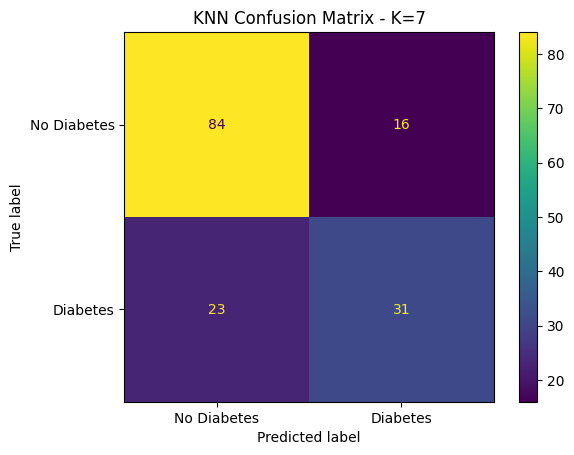

RESULTS FOR K = 9
Training Accuracy: 0.8013
Testing Accuracy : 0.7338
Precision        : 0.6383
Recall           : 0.5556
F1-Score         : 0.5941

              precision    recall  f1-score   support

 No Diabetes       0.78      0.83      0.80       100
    Diabetes       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



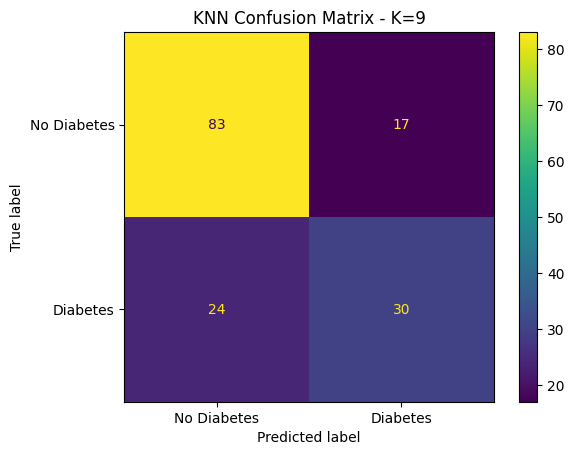

,K,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,1,1.000000,0.707792,0.588235,0.555556,0.571429
1,3,0.863192,0.694805,0.568627,0.537037,0.552381
2,5,0.806189,0.701299,0.583333,0.518519,0.549020
3,7,0.806189,0.746753,0.659574,0.574074,0.613861
4,9,0.801303,0.733766,0.638298,0.555556,0.594059


In [22]:
# Train and evaluate models with the required K values.
k_values = [1, 3, 5, 7, 9]

train_accuracy_results = []
test_accuracy_results = []

accuracy_results = []
precision_results = []
recall_results = []
f1_results = []

confusion_matrices = {}

for k in k_values:
    print("=" * 60)
    print(f"RESULTS FOR K = {k}")
    print("=" * 60)

    # Create and train the KNN model.
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    # Make predictions on both training and test data.
    train_predictions = knn_model.predict(X_train_scaled)
    predictions = knn_model.predict(X_test_scaled)

    # Calculate all classification metrics.
    model_train_accuracy = accuracy_score(y_train, train_predictions)
    model_test_accuracy = accuracy_score(y_test, predictions)
    model_precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    model_recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    model_f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    # Store the metric results.
    train_accuracy_results.append(model_train_accuracy)
    test_accuracy_results.append(model_test_accuracy)

    accuracy_results.append(model_test_accuracy)
    precision_results.append(model_precision)
    recall_results.append(model_recall)
    f1_results.append(model_f1)

    # Create and store the confusion matrix.
    cm = confusion_matrix(y_test, predictions)
    confusion_matrices[k] = cm

    print(f"Training Accuracy: {model_train_accuracy:.4f}")
    print(f"Testing Accuracy : {model_test_accuracy:.4f}")
    print(f"Precision        : {model_precision:.4f}")
    print(f"Recall           : {model_recall:.4f}")
    print(f"F1-Score         : {model_f1:.4f}")
    print()

    # Display the classification report.
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["No Diabetes", "Diabetes"],
            zero_division=0
        )
    )

    # Display the confusion matrix.
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )

    disp.plot()
    plt.title(f"KNN Confusion Matrix - K={k}")
    plt.show()

# Store all metric results in a table.
results = pd.DataFrame({
    "K": k_values,
    "Training Accuracy": train_accuracy_results,
    "Testing Accuracy": test_accuracy_results,
    "Precision": precision_results,
    "Recall": recall_results,
    "F1-Score": f1_results
})

display(results)

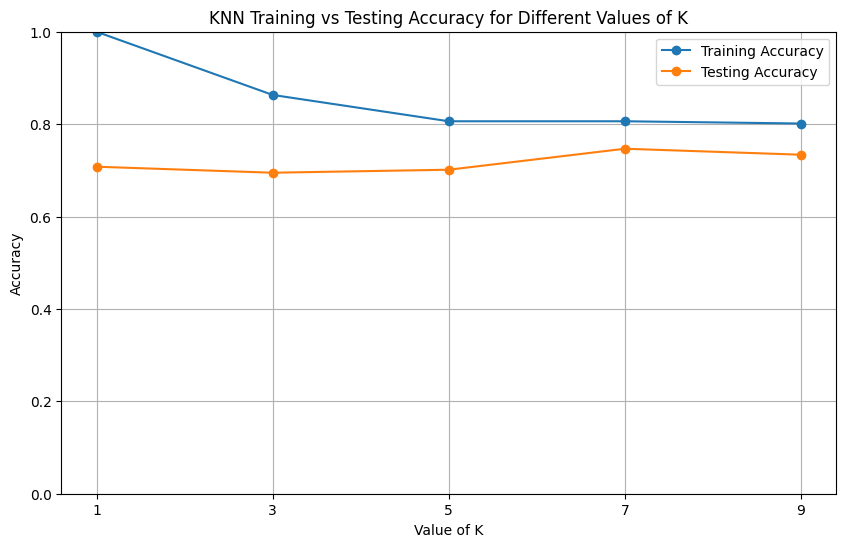

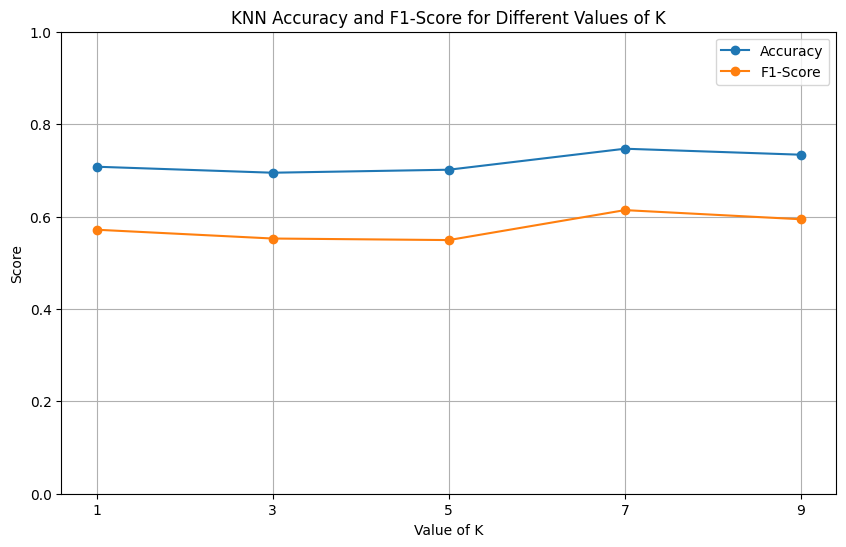

In [23]:
# Plot Training vs Testing Accuracy — same as class example.
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    train_accuracy_results,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    k_values,
    test_accuracy_results,
    marker="o",
    label="Testing Accuracy"
)

plt.title("KNN Training vs Testing Accuracy for Different Values of K")
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy and F1-Score — required by the assignment.
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    test_accuracy_results,
    marker="o",
    label="Accuracy"
)

plt.plot(
    k_values,
    f1_results,
    marker="o",
    label="F1-Score"
)

plt.title("KNN Accuracy and F1-Score for Different Values of K")
plt.xlabel("Value of K")
plt.ylabel("Score")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

In [24]:
# Identify the Best K
# Find the K with the highest accuracy.
best_accuracy_index = np.argmax(accuracy_results)
best_accuracy_k = k_values[best_accuracy_index]

# Find the K with the highest F1-score.
best_f1_index = np.argmax(f1_results)
best_f1_k = k_values[best_f1_index]

print(f"Best K based on Accuracy: {best_accuracy_k}")
print(f"Accuracy: {accuracy_results[best_accuracy_index]:.4f}")

print()

print(f"Best K based on F1-Score: {best_f1_k}")
print(f"F1-Score: {f1_results[best_f1_index]:.4f}")

Best K based on Accuracy: 7
Accuracy: 0.7468

Best K based on F1-Score: 7
F1-Score: 0.6139


## Experiment Interpretation

### What is K?
K represents the number of nearest neighboring observations that KNN uses to make a prediction. The model looks at the K closest training observations and assigns the class that appears most frequently among them.

### How Changing K Affects Performance

**K = 1 (Overfitting)**
When K = 1, the model uses only the single closest observation to make each prediction. Our results show a Training Accuracy of 100% but a Testing Accuracy of only 70.78%. This large gap is a clear sign of overfitting. The model memorized the training data instead of learning general patterns, so it performed poorly on unseen data.

**K = 3 and K = 5 (Underfitting)**
As K increased to 3 and 5, the training accuracy dropped and testing accuracy remained low at around 69–70%. The model became more general but was still not capturing the underlying patterns well enough.

**K = 7 (Best Performance)**
K = 7 produced the best results with a Testing Accuracy of 74.68% and the highest F1-Score of 0.6139. The gap between training accuracy (80.62%) and testing accuracy (74.68%) is much smaller than K = 1, which means the model is generalizing better to unseen data without overfitting.

**K = 9 (Beginning to Underfit)**
At K = 9, both accuracy and F1-Score began to drop slightly, suggesting the model was becoming too general.

### Why Feature Scaling Matters
KNN uses distance calculations to find the nearest neighbors. The diabetes dataset features have very different numerical ranges. For example, glucose values are much larger than the number of pregnancies. Without scaling, features with larger values would dominate the distance calculation and the model would effectively ignore smaller-scale features. `StandardScaler` transforms all features to a similar scale before training, giving each feature an equal contribution to the distance calculation.

### Recommended K
Based on this experiment, **K = 7** is the recommended value. It produced the highest Testing Accuracy (74.68%) and the highest F1-Score (0.6139), and showed the best balance between training and testing performance. In a medical classification problem like diabetes diagnosis, the F1-Score is particularly important because it balances both precision and recall, helping to reduce the number of missed diagnoses.